# 01 — Análise Exploratória (EDA)

**Dataset:** 2015 Flight Delays and Cancellations (U.S. DOT, ~5.8M voos).

**Objetivo deste notebook**:
1. Carregar e inspecionar o dataset com dtypes otimizados.
2. Estatísticas descritivas das variáveis numéricas e categóricas.
3. Análise de valores ausentes — decisões de tratamento.
4. Visualizações que respondem às perguntas-guia do desafio.
5. Conclusões que orientam a modelagem (notebooks 02-04).

**Perguntas que vamos responder**:
- Qual a distribuição do atraso? Qual % de voos atrasa ≥ 15 min?
- Quais aeroportos / companhias / dias / horários são mais críticos?
- Há padrão sazonal claro?
- Quais variáveis prometem como preditores?

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config
from src.data_loader import describe_dataset, load_airlines, load_airports, load_flights, memory_usage_mb
from src.preprocessing import missing_report
from src import visualization as viz

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("Configurações:")
print(f"  DATA_DIR     = {config.DATA_DIR}")
print(f"  SAMPLE_SIZE  = {config.SAMPLE_SIZE} (0 = dataset completo)")
print(f"  RANDOM_SEED  = {config.RANDOM_SEED}")

Configurações:
  DATA_DIR     = /Users/silviomeireles/projects/study/fiap-8mlet/fiap-tech-challenge-fase-3/data
  SAMPLE_SIZE  = 200000 (0 = dataset completo)
  RANDOM_SEED  = 42


## 1. Carregamento dos dados

Usamos `load_flights` com dtypes explícitos — reduz uso de memória de ~3 GB para ~700 MB.

In [2]:
flights = load_flights(sample_size=config.SAMPLE_SIZE)
airlines = load_airlines()
airports = load_airports()

print(f"flights:  {flights.shape[0]:>10,} linhas × {flights.shape[1]} colunas | {memory_usage_mb(flights):.1f} MB")
print(f"airlines: {airlines.shape}")
print(f"airports: {airports.shape}")

flights:     200,000 linhas × 31 colunas | 27.6 MB
airlines: (14, 2)
airports: (322, 7)


In [3]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,1335.0,-5.0,13.0,1348.0,56.0,48.0,30.0,128,1418.0,5.0,1436,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,1858.0,-12.0,14.0,1912.0,155.0,155.0,131.0,867,2123.0,10.0,2145,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,626.0,-4.0,8.0,634.0,110.0,106.0,92.0,672,806.0,6.0,820,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,1043.0,153.0,6.0,1049.0,100.0,99.0,85.0,546,1214.0,8.0,950,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,1008.0,8.0,16.0,1024.0,498.0,488.0,461.0,3904,1305.0,11.0,1318,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
flights.describe(include="number").T.round(2)

,count,mean,std,min,25%,50%,75%,max
YEAR,200000.0,2015.00,0.00,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,200000.0,6.52,3.41,1.0,4.0,7.0,9.0,12.0
DAY,200000.0,15.71,8.78,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,200000.0,3.91,1.99,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,200000.0,2171.04,1758.46,1.0,728.0,1686.0,3228.0,7438.0
SCHEDULED_DEPARTURE,200000.0,1329.13,483.18,3.0,917.0,1325.0,1730.0,2359.0
DEPARTURE_TIME,197128.0,1334.75,495.75,1.0,920.0,1330.0,1739.0,2400.0
DEPARTURE_DELAY,197128.0,9.44,37.35,-44.0,-5.0,-2.0,7.0,1576.0
TAXI_OUT,197029.0,16.04,8.89,1.0,11.0,14.0,19.0,225.0
WHEELS_OFF,197029.0,1356.76,497.27,1.0,935.0,1343.0,1753.0,2400.0


**Observações da estatística descritiva**:
- `ARRIVAL_DELAY` tem média positiva mas mediana ~ –5 min → maioria dos voos chega antes ou no horário; outliers à direita puxam a média.
- `DEPARTURE_DELAY` e `ARRIVAL_DELAY` têm cauda longa (max > 1.000 min ≈ 17h).
- Colunas `*_DELAY` granulares (AIRLINE_DELAY, WEATHER_DELAY, etc.) têm muitos NaN porque só são preenchidas quando o voo atrasa ≥ 15 min.

## 2. Valores ausentes

In [5]:
missing = missing_report(flights)
missing.head(15)

,missing,missing_pct,dtype
CANCELLATION_REASON,196998,98.499,category
WEATHER_DELAY,163387,81.694,float32
LATE_AIRCRAFT_DELAY,163387,81.694,float32
AIRLINE_DELAY,163387,81.694,float32
SECURITY_DELAY,163387,81.694,float32
AIR_SYSTEM_DELAY,163387,81.694,float32
AIR_TIME,3490,1.745,float32
ARRIVAL_DELAY,3490,1.745,float32
ELAPSED_TIME,3490,1.745,float32
WHEELS_ON,3089,1.544,float32


**Plano de tratamento** (implementado em `src.preprocessing.clean_pipeline`):

| Coluna(s) | Tratamento | Justificativa |
| :--- | :--- | :--- |
| `CANCELLATION_REASON` | descartar | só existe para voos cancelados; tarefa de cancelamento é fora do escopo |
| `*_DELAY` granulares | `fillna(0)` | NaN ≡ "sem contribuição" (voo não atrasou ≥ 15 min) |
| `TAIL_NUMBER` (~0.25%) | preencher `"UNKNOWN"` | manter linha; impacto pequeno |
| `ARRIVAL_DELAY`, `DEPARTURE_TIME` (~1.5%) | dropar | correspondem a voos cancelados/desviados; tarefa deles é outra |

In [6]:
from src.preprocessing import clean_pipeline
from src.features import feature_pipeline

clean = clean_pipeline(flights)
clean = feature_pipeline(clean)
print(f"Após limpeza: {clean.shape[0]:>10,} linhas ({len(clean) / len(flights):.1%} do total)")

Após limpeza:    196,510 linhas (98.3% do total)


## 3. Variável alvo — `IS_DELAYED` (atraso ≥ 15 min na chegada)

In [7]:
rate = clean["IS_DELAYED"].mean()
print(f"Taxa global de atraso (≥15 min): {rate:.2%}")
print(f"Atraso médio na chegada: {clean['ARRIVAL_DELAY'].mean():.1f} min")
print(f"Atraso mediano na chegada: {clean['ARRIVAL_DELAY'].median():.1f} min")

Taxa global de atraso (≥15 min): 18.63%
Atraso médio na chegada: 4.5 min
Atraso mediano na chegada: -5.0 min


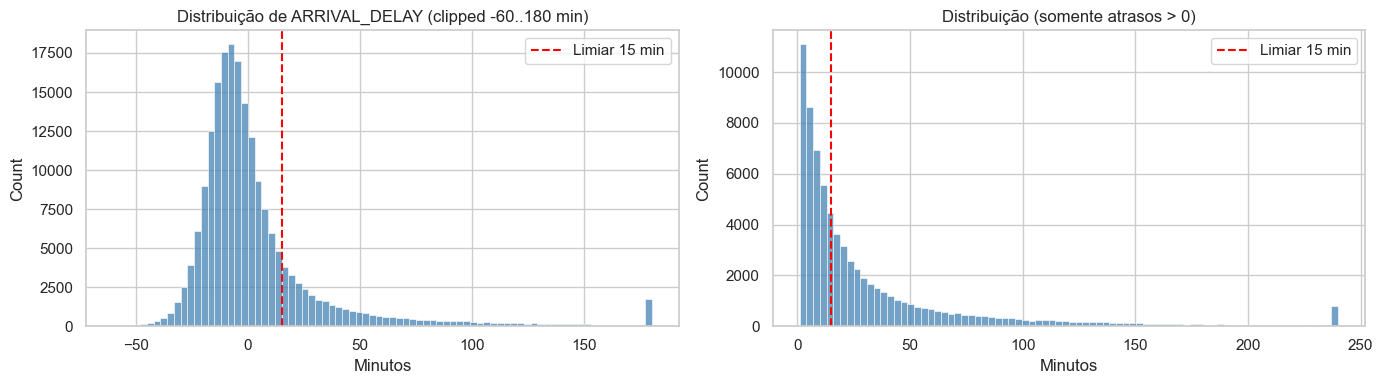

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
viz.plot_delay_distribution(clean, "ARRIVAL_DELAY", clip=(-60, 180), ax=axes[0])
viz.plot_delay_distribution(clean[clean["ARRIVAL_DELAY"] > 0], "ARRIVAL_DELAY", clip=(0, 240), ax=axes[1])
axes[1].set_title("Distribuição (somente atrasos > 0)")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "01_arrival_delay_distribution.png", dpi=120)
plt.show()

## 4. Atraso por dimensões

### 4.1 Companhia aérea

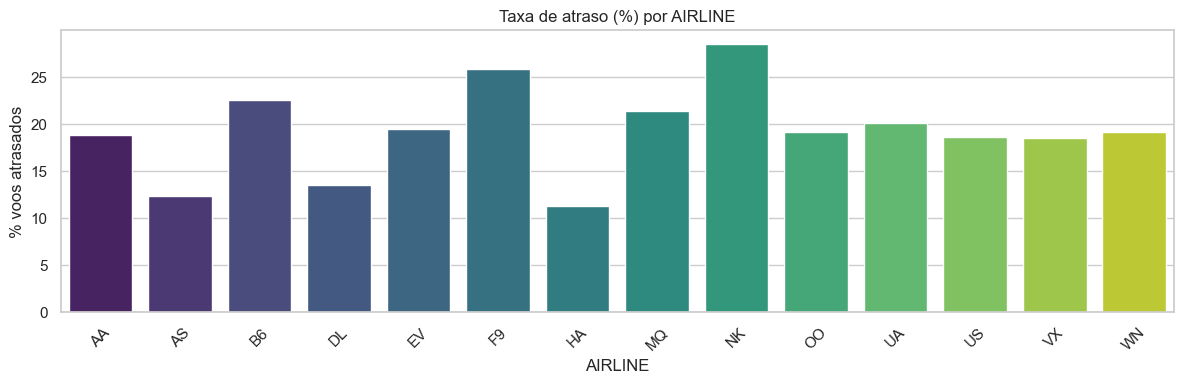

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
viz.plot_delay_rate_by(clean, "AIRLINE", ax=ax)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "02_delay_by_airline.png", dpi=120)
plt.show()

### 4.2 Aeroporto de origem — top 25 piores

In [10]:
airport_stats = (
    clean.groupby("ORIGIN_AIRPORT", observed=True)
    .agg(n_flights=("IS_DELAYED", "size"), delay_rate=("IS_DELAYED", "mean"))
    .query("n_flights >= 10000")
    .sort_values("delay_rate", ascending=False)
)
print("Top 10 aeroportos por taxa de atraso (≥10k voos no ano):")
airport_stats.head(10).round(3)

Top 10 aeroportos por taxa de atraso (≥10k voos no ano):


,n_flights,delay_rate
ORIGIN_AIRPORT,,
ATL,11735,0.157


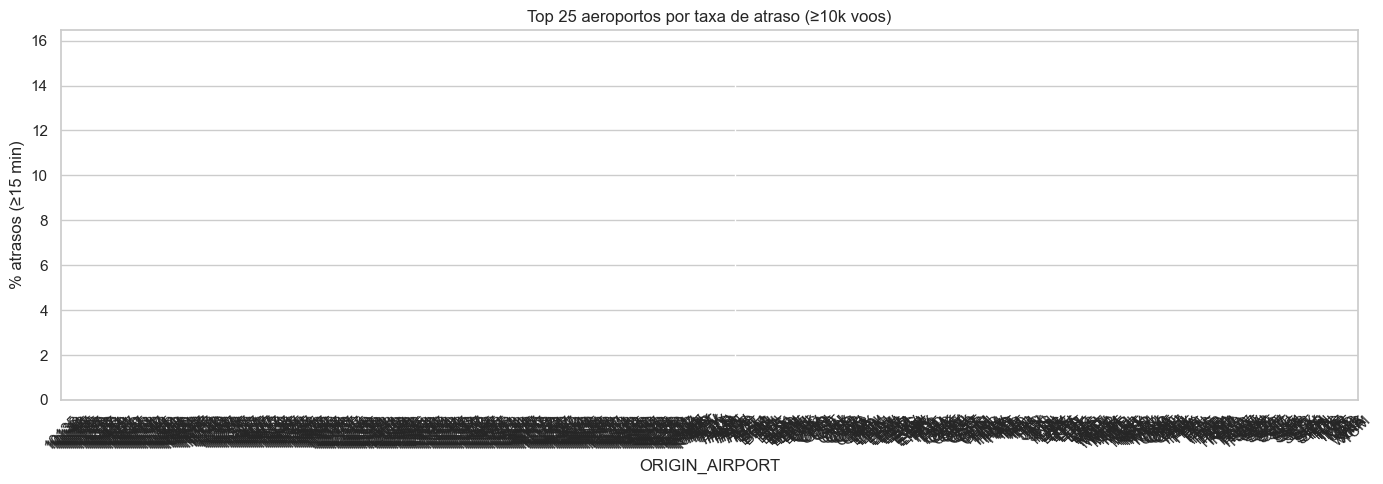

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
top25 = airport_stats.head(25)
sns.barplot(x=top25.index, y=top25["delay_rate"] * 100, hue=top25.index, ax=ax, palette="rocket_r", legend=False)
ax.set_title("Top 25 aeroportos por taxa de atraso (≥10k voos)")
ax.set_ylabel("% atrasos (≥15 min)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_delay_by_airport.png", dpi=120)
plt.show()

### 4.3 Heatmap dia da semana × hora do dia

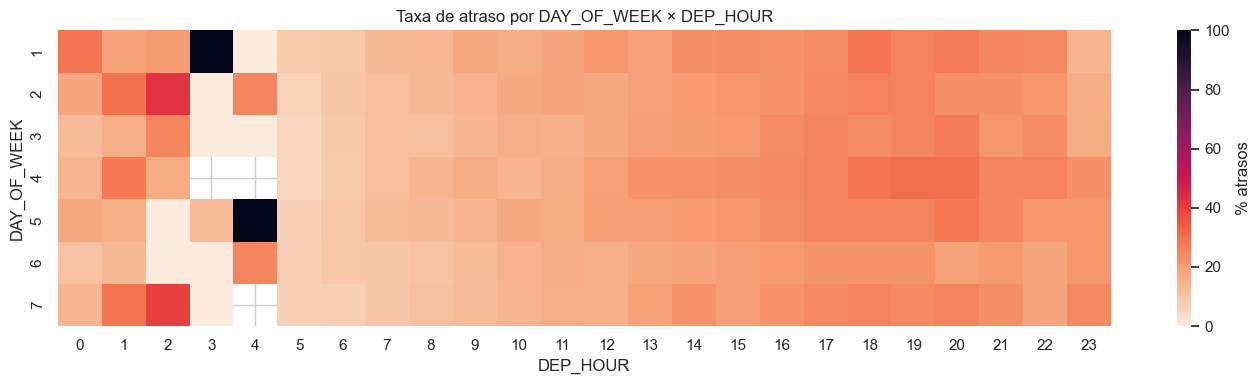

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
viz.plot_delay_heatmap(clean, row="DAY_OF_WEEK", col="DEP_HOUR", ax=ax)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_heatmap_day_hour.png", dpi=120)
plt.show()

### 4.4 Sazonalidade — mês e estação do ano

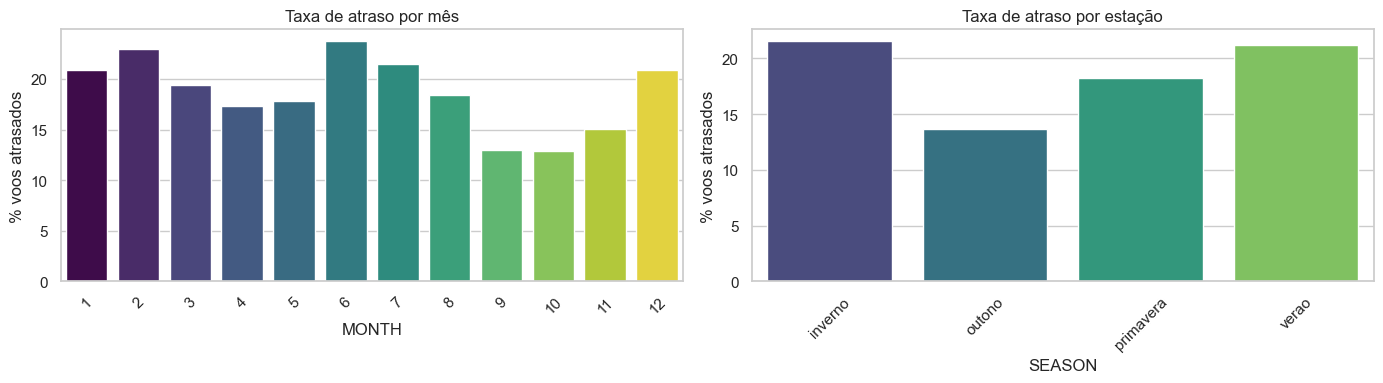

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
viz.plot_delay_rate_by(clean, "MONTH", ax=axes[0])
axes[0].set_title("Taxa de atraso por mês")
viz.plot_delay_rate_by(clean, "SEASON", ax=axes[1])
axes[1].set_title("Taxa de atraso por estação")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "05_seasonality.png", dpi=120)
plt.show()

### 4.5 Feriados e fins de semana

In [14]:
comp = pd.DataFrame({
    "Fim de semana": clean.groupby("IS_WEEKEND")["IS_DELAYED"].mean(),
    "Feriado federal": clean.groupby("IS_HOLIDAY")["IS_DELAYED"].mean(),
}).round(4) * 100
comp.index = ["Não", "Sim"]
print("Taxa de atraso (%):")
comp

Taxa de atraso (%):


,Fim de semana,Feriado federal
Não,19.17,18.73
Sim,17.10,15.82


## 5. Causas de atraso

Para os voos que efetivamente atrasaram (≥15 min), qual o peso médio de cada causa?

In [15]:
delayed = clean[clean["IS_DELAYED"] == 1]
reason_share = (
    delayed[config.DELAY_REASON_COLS]
    .sum()
    .pipe(lambda s: s / s.sum() * 100)
    .round(2)
    .sort_values(ascending=False)
)
print("Contribuição percentual ao total de minutos atrasados:")
reason_share

Contribuição percentual ao total de minutos atrasados:


LATE_AIRCRAFT_DELAY    39.759998
AIRLINE_DELAY          32.320000
AIR_SYSTEM_DELAY       22.700001
WEATHER_DELAY           5.060000
SECURITY_DELAY          0.160000
dtype: float32

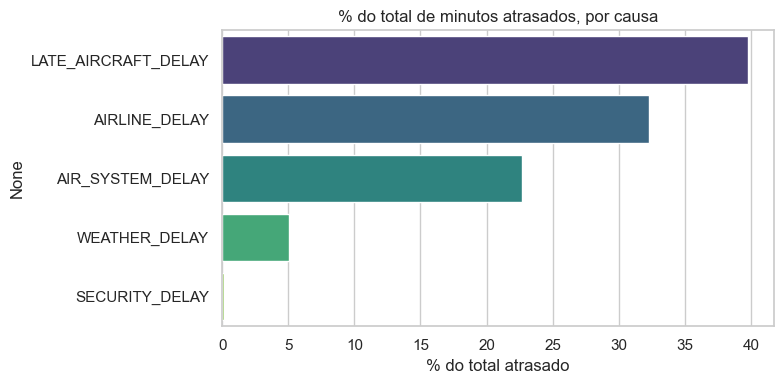

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=reason_share.values, y=reason_share.index, hue=reason_share.index, palette="viridis", ax=ax, legend=False)
ax.set_title("% do total de minutos atrasados, por causa")
ax.set_xlabel("% do total atrasado")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "06_delay_causes.png", dpi=120)
plt.show()

## 6. Correlação entre numéricas selecionadas

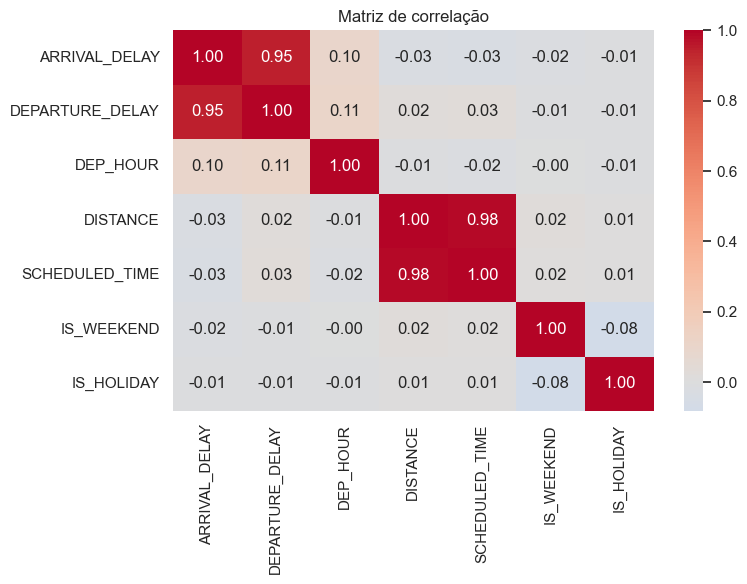

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
viz.plot_correlation_matrix(
    clean,
    cols=["ARRIVAL_DELAY", "DEPARTURE_DELAY", "DEP_HOUR", "DISTANCE", "SCHEDULED_TIME", "IS_WEEKEND", "IS_HOLIDAY"],
    ax=ax,
)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "07_correlation.png", dpi=120)
plt.show()

## 7. Conclusões da EDA

1. **Desbalanceamento moderado**: ~18-20% dos voos atrasam ≥ 15 min. Suficiente para predição, mas exige métricas além de accuracy (precision/recall, ROC-AUC, PR-AUC).
2. **Dimensões mais discriminativas** observadas: hora do dia (claro crescimento ao longo do dia), companhia aérea, aeroporto de origem, mês (jun/jul/dez piores) e feriados.
3. **Causa dominante**: atraso por *aircraft tardio* (efeito cascata) + companhia + NAS — o tempo agudo aparece concentrado, mas o efeito "propagação" domina.
4. **Vazamento a evitar**: `DEPARTURE_DELAY`, `TAXI_OUT`, `WHEELS_*`, `AIR_TIME` e os `*_DELAY` granulares só são conhecidos *após* o voo. Já listados em `config.LEAKY_COLS` e *não* serão usados como preditores nos notebooks 02/03.
5. **Features fortes para modelagem**: AIRLINE, ORIGIN_AIRPORT, DESTINATION_AIRPORT, DEP_HOUR, MONTH, DAY_OF_WEEK, IS_HOLIDAY, DISTANCE, SCHEDULED_TIME.

Próximos notebooks:
- **02_classification.ipynb** — predição binária `IS_DELAYED`.
- **03_regression.ipynb** — predição da duração do atraso.
- **04_unsupervised.ipynb** — clusterização de aeroportos + PCA.